# Import Libraries

In [9]:
import tensorflow as tf
import pandas as pd
import numpy as np

# plotting
import matplotlib.pyplot as plt

#Model Production
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error,root_mean_squared_error, r2_score

# Preprocessing

### Loading

In [10]:
#Load the dataset and look at the info of the dataset
csv_path = "/Users/deadfloppy/Projects/MANU465 AI/project/concrete_data.csv"
dataset = pd.read_csv(csv_path)

#Seperate the input (x) data T, AP, RH, and V data from the output (y) data EP 
x_data = dataset.iloc[:, :-1].values
y_data = dataset.iloc[:,-1].values
x_data
# y_data

array([[ 540. ,    0. ,    0. , ..., 1040. ,  676. ,   28. ],
       [ 540. ,    0. ,    0. , ..., 1055. ,  676. ,   28. ],
       [ 332.5,  142.5,    0. , ...,  932. ,  594. ,  270. ],
       ...,
       [ 148.5,  139.4,  108.6, ...,  892.4,  780. ,   28. ],
       [ 159.1,  186.7,    0. , ...,  989.6,  788.9,   28. ],
       [ 260.9,  100.5,   78.3, ...,  864.5,  761.5,   28. ]])

In [11]:
#Use the sklearn.model_selection train_test_split function to split the data, set random state = 1 for reproducibiltiy
x_train, x_test, y_train, y_test = train_test_split(x_data, y_data, test_size=0.25, random_state=1)

#Set the StandardScaler function for easy implementation
x_scaler = StandardScaler().set_output(transform='pandas')
y_scaler = StandardScaler()

x_train = x_scaler.fit_transform(x_train)
x_test  = x_scaler.transform(x_test)
y_train = y_scaler.fit_transform(y_train.reshape(-1, 1))
y_test  = y_scaler.transform(y_test.reshape(-1, 1))

# Model 3: ANN

In [12]:
# Data augmentation: 20x Gaussian noise copies to improve training
np.random.seed(42)
aug_factor = 20
x_train_aug = np.tile(x_train, (aug_factor, 1)) + np.random.normal(0, 0.02, (len(x_train)*aug_factor, x_train.shape[1]))
y_train_aug = np.tile(y_train.flatten(), aug_factor) + np.random.normal(0, 0.005, len(y_train)*aug_factor)
print(f"Augmented training size: {len(x_train_aug)} (from {len(x_train)})")

Augmented training size: 15440 (from 772)


Epoch 1/500
121/121 [==============================] - 3s 15ms/step - loss: 0.2708 - mae: 0.3890 - val_loss: 0.5009 - val_mae: 0.5932 - lr: 0.0010
Epoch 2/500
121/121 [==============================] - 1s 11ms/step - loss: 0.1469 - mae: 0.2963 - val_loss: 0.3922 - val_mae: 0.5324 - lr: 0.0010
Epoch 3/500
121/121 [==============================] - 1s 11ms/step - loss: 0.1256 - mae: 0.2728 - val_loss: 0.2516 - val_mae: 0.4127 - lr: 0.0010
Epoch 4/500
121/121 [==============================] - 1s 10ms/step - loss: 0.1042 - mae: 0.2492 - val_loss: 0.1612 - val_mae: 0.3012 - lr: 0.0010
Epoch 5/500
121/121 [==============================] - 1s 10ms/step - loss: 0.0995 - mae: 0.2430 - val_loss: 0.1360 - val_mae: 0.2587 - lr: 0.0010
Epoch 6/500
121/121 [==============================] - 1s 11ms/step - loss: 0.0963 - mae: 0.2399 - val_loss: 0.1479 - val_mae: 0.2806 - lr: 0.0010
Epoch 7/500
121/121 [==============================] - 1s 10ms/step - loss: 0.0835 - mae: 0.2224 - val_loss: 0.1305 - 

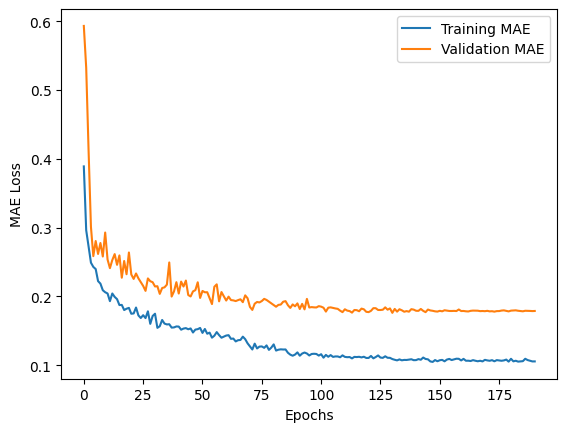

In [13]:
# Initialize model
#reg = tf.keras.regularizers.l2(1e-5)
act_func = 'elu'
model = tf.keras.Sequential([
    # tf.keras.layers.Dense(1024, activation=act_func, kernel_regularizer=reg),
    # tf.keras.layers.BatchNormalization(),
    # tf.keras.layers.Dense(512, activation=act_func, kernel_regularizer=reg),
    # tf.keras.layers.BatchNormalization(),
    # tf.keras.layers.Dense(256, activation=act_func, kernel_regularizer=reg),
    # tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dense(128, activation=act_func, kernel_regularizer=reg),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dense(64, activation=act_func),
    tf.keras.layers.Dense(32, activation=act_func),
    tf.keras.layers.Dense(1)
])

learning_rate = 0.001
model.compile(optimizer=tf.keras.optimizers.legacy.Adam(learning_rate), loss='mse', metrics=['mae'])

early_stop = tf.keras.callbacks.EarlyStopping(patience=60, restore_best_weights=True, monitor='val_mae')
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=15, min_lr=1e-7, monitor='val_mae')

history = model.fit(
    x_train_aug, y_train_aug,
    validation_data=(x_test, y_test),
    batch_size=128, epochs=500, verbose=1,
    callbacks=[early_stop, reduce_lr]
)
model.summary()

# Training history
plt.plot(history.history['mae'], label="Training MAE")
plt.plot(history.history['val_mae'], label="Validation MAE")
plt.xlabel("Epochs")
plt.ylabel("MAE Loss")
plt.legend()
plt.show()

# Model Evaluation

9/9 [==============================] - 0s 4ms/step
MAE:  2.9618 MPa
MSE:  24.2482 MPa²
RMSE: 4.9242 MPa
R²:   0.9091


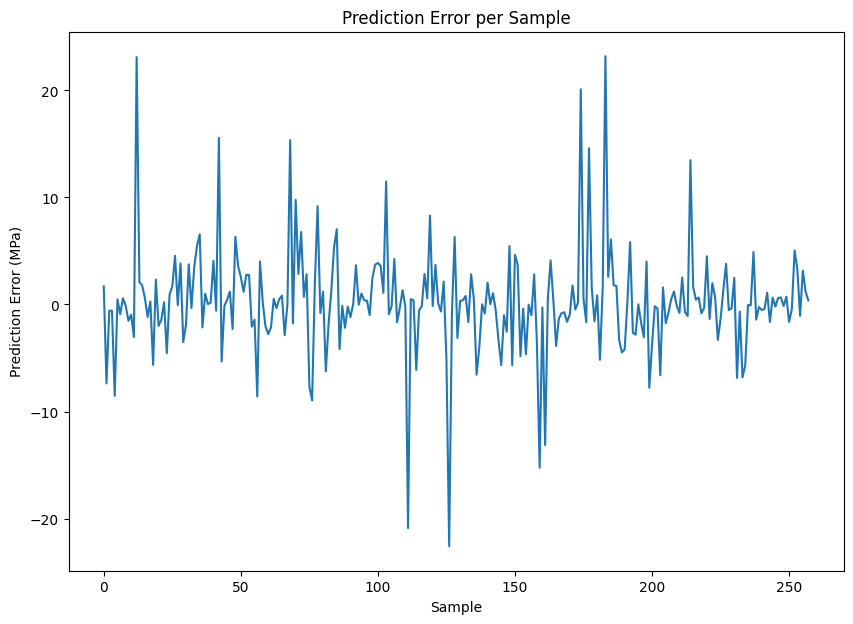

In [14]:
y_pred = model.predict(x_test)
y_pred_sc = y_scaler.inverse_transform(y_pred)
y_test_sc = y_scaler.inverse_transform(y_test)

err = y_pred_sc - y_test_sc

mae = mean_absolute_error(y_test_sc, y_pred_sc)
mse = mean_squared_error(y_test_sc, y_pred_sc)
r2 = r2_score(y_test_sc, y_pred_sc)

print(f"MAE:  {mae:.4f} MPa")
print(f"MSE:  {mse:.4f} MPa²")
print(f"RMSE: {np.sqrt(mse):.4f} MPa")
print(f"R²:   {r2:.4f}")

fig, ax = plt.subplots(1, 1, figsize=[10, 7])
ax.plot(range(len(err)), err)
ax.set_xlabel("Sample")
ax.set_ylabel("Prediction Error (MPa)")
ax.set_title("Prediction Error per Sample")
plt.show()